# Caso 1 — Mensual | Negativos→0, ceros se mantienen

**Descripción del caso:** Los negativos (devoluciones) se reemplazan por 0. Los meses con 0 ventas se mantienen como están — el modelo aprende que puede haber meses sin demanda.

---

## 1. Instalación e imports

Corré esta celda primero para instalar las dependencias necesarias.

In [2]:
# Instalación (solo la primera vez)
# !pip install xgboost pandas openpyxl scikit-learn matplotlib

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

try:
    import xgboost as xgb
    USE_XGB = True
    print("✅ XGBoost cargado correctamente")
except ImportError:
    from sklearn.ensemble import GradientBoostingRegressor
    USE_XGB = False
    print("⚠️  XGBoost no encontrado — usando GradientBoostingRegressor (instala con: pip install xgboost)")


✅ XGBoost cargado correctamente


## 2. Carga y limpieza de datos

**Criterio aplicado:** Negativos → 0  |  Ceros se mantienen tal cual

Registros cargados: 6865
Negativos encontrados: 90
Ceros encontrados: 75
Rango: 2021-01-01 → 2026-02-01

Serie final: 62 meses
Demanda promedio mensual: 2870


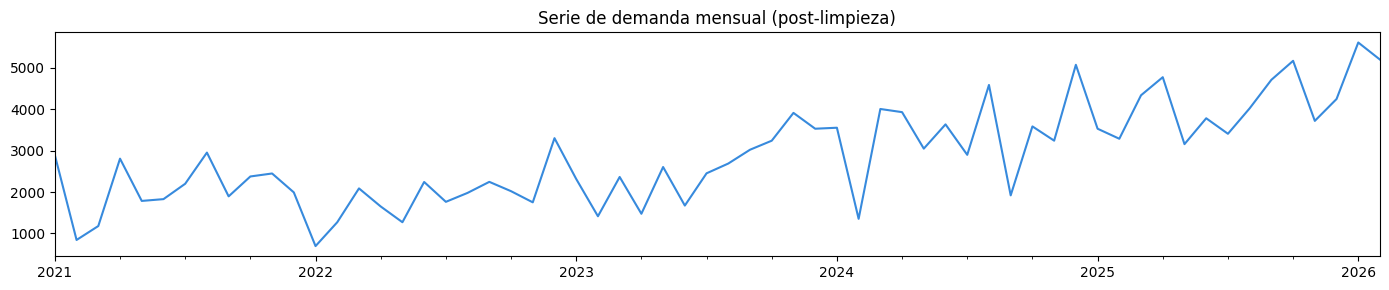

In [4]:
# ── Carga de datos ──────────────────────────────────────────
ARCHIVO = "G:\My Drive\ElCapstone\Capstone\clari\ChocloNorteTotal.xlsx"   # ajustá el path si es necesario
PRODUCTO_ID = 219140001    # Choclo Norte Total

df = pd.read_excel(ARCHIVO, sheet_name="Datos Producto")
df = df[df["Producto"] == PRODUCTO_ID].copy()
df["Mes"] = pd.to_datetime(df["Mes"])
df = df.sort_values("Mes").reset_index(drop=True)

print(f"Registros cargados: {len(df)}")
print(f"Negativos encontrados: {(df['Demanda'] < 0).sum()}")
print(f"Ceros encontrados: {(df['Demanda'] == 0).sum()}")
print(f"Rango: {df['Mes'].min().date()} → {df['Mes'].max().date()}")

# ── Limpieza — Los negativos (devoluciones) se reemplazan por 0.  ──
# CASO 1: Negativos → 0, ceros se mantienen
df["Demanda"] = df["Demanda"].clip(lower=0)
ts = df.groupby("Mes")["Demanda"].sum()
ts = ts.reindex(pd.date_range(ts.index.min(), ts.index.max(), freq="MS"))
ts = ts.fillna(ts.median())

print(f"\nSerie final: {len(ts)} meses")
print(f"Demanda promedio mensual: {ts.mean():.0f}")
ts.plot(figsize=(14, 3), title="Serie de demanda mensual (post-limpieza)", color="#378ADD")
plt.tight_layout(); plt.show()


## 3. Features para XGBoost

XGBoost no entiende fechas directamente. Necesitamos convertir la información temporal en columnas numéricas: lags, medias móviles, y variables de calendario.

In [5]:
def construir_features(ts):
    """
    Construye las variables de entrada (features) para XGBoost.
    XGBoost no entiende fechas directamente — necesitamos convertir
    la información temporal en columnas numéricas.
    
    Lags: valor de períodos anteriores (ej: lag_1 = demanda del mes pasado).
          Son la base de la predicción — el modelo aprende que si el mes
          pasado se vendió mucho, este mes probablemente también.
    
    Rolling stats: estadísticas de ventanas deslizantes.
          Capturan tendencia reciente sin depender de un solo período.
    """
    df = pd.DataFrame({"y": ts}).reset_index()
    df.columns = ["fecha", "y"]
    
    df["mes_num"]   = df["fecha"].dt.month       # estacionalidad mensual
    df["trimestre"] = df["fecha"].dt.quarter      # estacionalidad trimestral
    df["año"]       = df["fecha"].dt.year         # tendencia anual
    df["t"]         = range(len(df))              # tendencia lineal
    
    # Lags (usamos shift para no filtrar el futuro)
    for lag in [1, 2, 3, 4, 6, 12]:
        df[f"lag_{lag}"] = df["y"].shift(lag)
    
    # Rolling stats sobre lag-1 (nunca sobre el valor actual)
    for v in [3, 6]:
        df[f"roll_mean_{v}"] = df["y"].shift(1).rolling(v).mean()
        df[f"roll_std_{v}"]  = df["y"].shift(1).rolling(v).std()
        df[f"roll_max_{v}"]  = df["y"].shift(1).rolling(v).max()
    
    df["diff_1"] = df["y"].diff(1)   # cambio respecto al mes anterior
    
    return df.dropna().reset_index(drop=True)


## 4. Modelo XGBoost

Hiperparámetros usados y por qué:

In [6]:
def construir_modelo():
    """
    Hiperparámetros de XGBoost explicados:
      n_estimators  : cuántos árboles construye (más = más preciso pero más lento)
      learning_rate : qué tan grande es cada paso de aprendizaje (menor = más fino)
      max_depth     : profundidad de cada árbol (más = aprende patrones más complejos)
      subsample     : fracción de datos usada por árbol (evita overfitting)
      colsample_bytree: fracción de features usada por árbol
      min_child_weight: mínimo de muestras en una hoja (regularización)
    """
    if USE_XGB:
        return xgb.XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
            min_child_weight=3,
            reg_alpha=0.1,
            reg_lambda=1.0,
            random_state=42,
            verbosity=0
        )
    else:
        return GradientBoostingRegressor(
            n_estimators=300, learning_rate=0.05,
            max_depth=4, subsample=0.8, random_state=42
        )


## 5. Walk-Forward Cross-Validation

Esta es la forma correcta de evaluar modelos de series temporales.

Cada predicción usa **solo datos del pasado** — simulamos el modelo en producción real.

- Mínimo de historia: **24 meses** antes de la primera predicción

In [7]:
def walk_forward_cv(ts, min_train=24):
    """
    Walk-Forward Cross-Validation — la forma CORRECTA de evaluar modelos de series temporales.
    
    ¿Por qué no usar train/test split simple?
    → Con un split simple, el modelo puede "ver" patrones futuros en el test set
      de forma indirecta. En series temporales eso da métricas optimistas y falsas.
    
    ¿Cómo funciona walk-forward?
    → Paso 1: Entrena con meses 1 a 24, predice el mes 25
    → Paso 2: Entrena con meses 1 a 25, predice el mes 26
    → Paso 3: Entrena con meses 1 a 26, predice el mes 27
    → ... así hasta el final
    
    Cada predicción usa SOLO información del pasado. Es como simular
    el modelo en producción real.
    
    min_train=24 → necesitamos al menos 2 años de historia para empezar
    """
    df = construir_features(ts)
    feature_cols = [c for c in df.columns if c not in ["fecha", "y"]]
    X = df[feature_cols].values
    y = df["y"].values
    fechas = df["fecha"].values

    actuals, preds, dates = [], [], []

    for i in range(min_train, len(df)):
        model = construir_modelo()
        model.fit(X[:i], y[:i])
        pred = float(model.predict(X[i:i+1])[0])
        preds.append(max(0, pred))   # demanda no puede ser negativa
        actuals.append(float(y[i]))
        dates.append(pd.Timestamp(fechas[i]))

    return np.array(actuals), np.array(preds), dates
    

## 6. Correr el modelo

In [8]:
min_train = 24
print("Corriendo Walk-Forward CV...")
print(f"Serie: {len(ts)} meses | Primeras predicciones a partir del período {min_train+1}")
print()

actuals, preds, dates = walk_forward_cv(ts, min_train=24)

print(f"✅ Predicciones generadas: {len(preds)} puntos")


Corriendo Walk-Forward CV...
Serie: 62 meses | Primeras predicciones a partir del período 25

✅ Predicciones generadas: 26 puntos


## 7. Métricas de evaluación

Explicación de cada métrica:

In [9]:
def calcular_metricas(actuals, preds):
    """
    Métricas para evaluar predicción de demanda:
    
    MAE   → error absoluto medio en unidades. Fácil de interpretar.
            Ej: MAE=150 significa que en promedio nos equivocamos 150 unidades.
    
    RMSE  → similar al MAE pero penaliza más los errores grandes.
            Útil para detectar si hay meses con error muy alto.
    
    MAPE  → error en porcentaje. Ej: 20% = nos equivocamos 20% del valor real.
            ⚠️ Puede explotar si hay valores reales muy cercanos a 0.
    
    SMAPE → versión más robusta del MAPE. Usa el promedio de real+predicho
            en el denominador, evitando la inestabilidad del MAPE.
            Es la métrica principal a comparar entre casos.
    
    Bias  → sesgo sistemático del modelo.
            Bias > 0 → el modelo SOBREESTIMA (predice más de lo real)
            Bias < 0 → el modelo SUBESTIMA (predice menos de lo real)
            Bias ideal = 0
    
    R²    → qué % de la varianza explica el modelo.
            R²=1 → perfecto | R²=0 → igual que predecir el promedio | R²<0 → malo
    """
    mae  = mean_absolute_error(actuals, preds)
    rmse = np.sqrt(mean_squared_error(actuals, preds))
    
    mask = actuals > 0
    mape = np.mean(np.abs((actuals[mask] - preds[mask]) / actuals[mask])) * 100
    
    smape = np.mean(2 * np.abs(actuals - preds) / (np.abs(actuals) + np.abs(preds) + 1e-9)) * 100
    
    bias = np.mean(preds - actuals)
    
    ss_res = np.sum((actuals - preds) ** 2)
    ss_tot = np.sum((actuals - actuals.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else float("nan")
    
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape, "SMAPE": smape, "Bias": bias, "R2": r2}

def imprimir_metricas(m):
    print("=" * 45)
    print(f"  MAE    : {m['MAE']:>8.1f}  unidades por período")
    print(f"  RMSE   : {m['RMSE']:>8.1f}  penaliza errores grandes")
    print(f"  MAPE   : {m['MAPE']:>7.2f}%")
    print(f"  SMAPE  : {m['SMAPE']:>7.2f}%  ← métrica principal")
    print(f"  Bias   : {m['Bias']:>+8.1f}  (+ sobreestima / - subestima)")
    print(f"  R²     : {m['R2']:>8.3f}")
    print("=" * 45)


In [10]:
metricas = calcular_metricas(actuals, preds)
imprimir_metricas(metricas)


  MAE    :    694.1  unidades por período
  RMSE   :    860.6  penaliza errores grandes
  MAPE   :   21.04%
  SMAPE  :   19.78%  ← métrica principal
  Bias   :   -328.9  (+ sobreestima / - subestima)
  R²     :    0.194


## 8. Visualización

In [11]:
def graficar(dates, actuals, preds, titulo):
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    
    # Gráfico 1: real vs predicho
    axes[0].plot(dates, actuals, label="Real", color="#378ADD", linewidth=2)
    axes[0].plot(dates, preds, label="Predicho", color="#D85A30",
                 linewidth=2, linestyle="--")
    axes[0].fill_between(dates, actuals, preds, alpha=0.1, color="#D85A30")
    axes[0].set_title(titulo, fontsize=13, fontweight="bold")
    axes[0].set_ylabel("Demanda")
    axes[0].legend()
    axes[0].grid(axis="y", alpha=0.3)
    
    # Gráfico 2: error por período
    errores = np.array(preds) - np.array(actuals)
    colores = ["#D85A30" if e > 0 else "#378ADD" for e in errores]
    axes[1].bar(dates, errores, color=colores, alpha=0.7, width=20)
    axes[1].axhline(0, color="black", linewidth=0.8)
    axes[1].set_title("Error de predicción (Predicho − Real)", fontsize=11)
    axes[1].set_ylabel("Error (unidades)")
    axes[1].grid(axis="y", alpha=0.3)
    
    plt.tight_layout()
    plt.show()


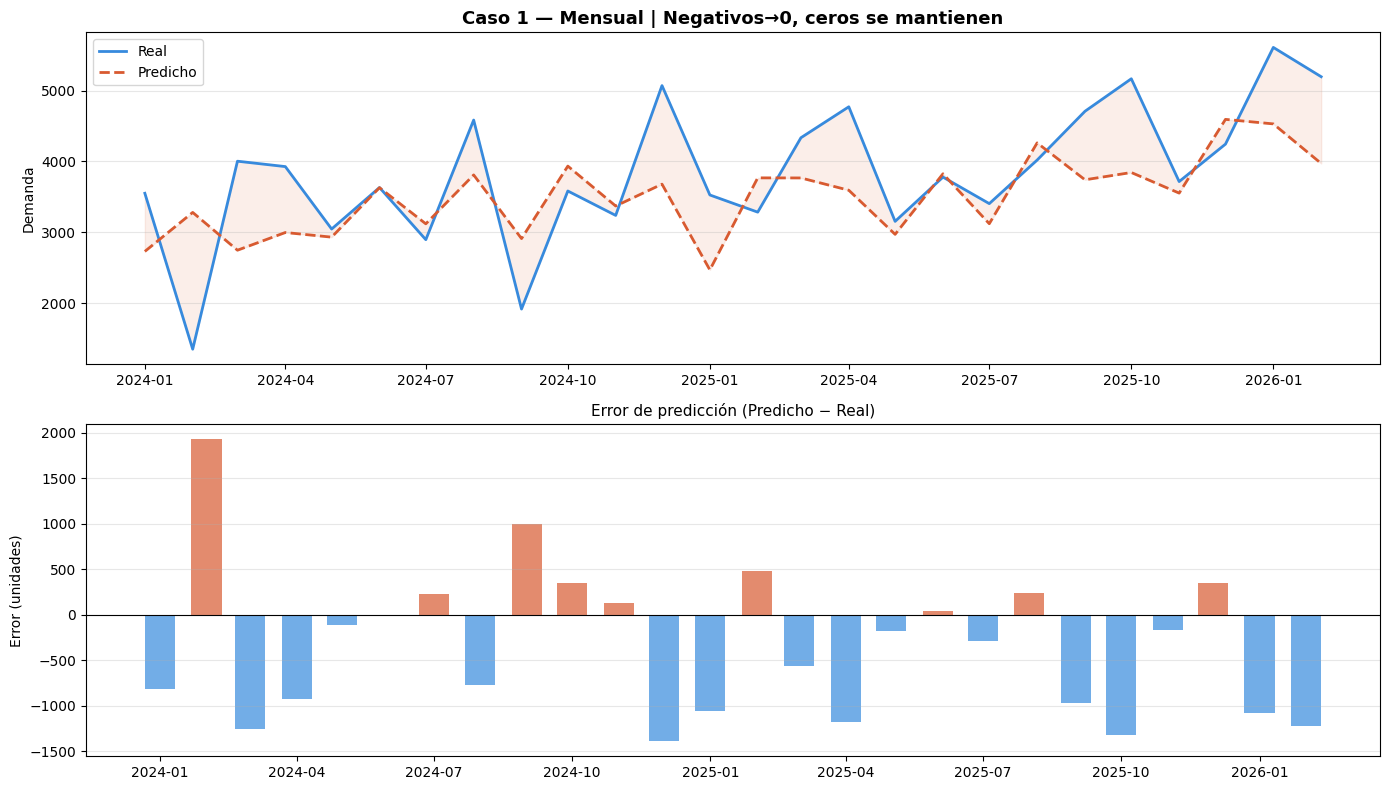

In [12]:
graficar(dates, actuals, preds, "Caso 1 — Mensual | Negativos→0, ceros se mantienen")

## 9. Resumen

Guardá estos resultados para comparar con los otros notebooks.

In [13]:
print("\n📋 RESUMEN PARA COMPARACIÓN")
print("=" * 45)
print(f"Notebook : Caso 1 — Mensual | Negativos→0, ceros se mantienen")
print(f"Períodos evaluados: {len(actuals)} meses")
print(f"SMAPE  : {metricas['SMAPE']:.2f}%  ← métrica principal")
print(f"MAE    : {metricas['MAE']:.1f} unidades")
print(f"RMSE   : {metricas['RMSE']:.1f} unidades")
print(f"Bias   : {metricas['Bias']:+.1f} (+ sobreestima / - subestima)")
print(f"R²     : {metricas['R2']:.3f}")
print("=" * 45)
print("\n⬆️  Copiá estos valores al notebook de comparacion_final.ipynb")



📋 RESUMEN PARA COMPARACIÓN
Notebook : Caso 1 — Mensual | Negativos→0, ceros se mantienen
Períodos evaluados: 26 meses
SMAPE  : 19.78%  ← métrica principal
MAE    : 694.1 unidades
RMSE   : 860.6 unidades
Bias   : -328.9 (+ sobreestima / - subestima)
R²     : 0.194

⬆️  Copiá estos valores al notebook de comparacion_final.ipynb
